In [ ]:
!pip install -q httpx pandas matplotlib

In [1]:
import asyncio
import httpx
import time
import random
import statistics
from dataclasses import dataclass, asdict
from typing import List, Dict, Any, Optional

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
BASE_URL = "http://192.168.1.166:58002"   # Infinity 서버 주소로 수정
# BASE_URL = "http://127.0.0.1:58002"   # Infinity 서버 주소로 수정
RERANK_ENDPOINT = "/rerank"
MODELS_ENDPOINT = "/models"

TIMEOUT = 600.0

# # 테스트 강도
# REQUESTS_PER_ROUND = 8
# CONCURRENCY_LEVELS = [1, 2, 4]

# # payload 크기
# DOCS_PER_REQUEST = 2
# QUERY_REPEAT = 2
# DOC_REPEAT = 4
# TOP_N = 2


DOCS_PER_REQUEST = 4
QUERY_REPEAT = 4
DOC_REPEAT = 10
TOP_N = 3

REQUESTS_PER_ROUND = 8
CONCURRENCY_LEVELS = [1, 2, 4]

random.seed(42)

# 긴 한국어/영어 혼합 텍스트 생성기

In [3]:
BASE_QUERY_SENTENCES = [
    "이 문서는 사내 AI 플랫폼의 공용 리랭커 서비스 설계와 운영 방안을 설명합니다.",
    "주요 관심사는 GPU 자체의 연산 속도보다 CPU 토크나이징 병목과 동시성 처리 방식입니다.",
    "특히 다수의 내부 시스템이 동시에 요청을 보내는 상황에서 배치 처리 효율을 확인하고 싶습니다.",
    "문서 길이가 길고 query-document pair가 충분히 큰 경우에도 안정적으로 처리되는지 확인해야 합니다.",
    "이 테스트는 실제 운영 트래픽을 단순화한 synthetic workload입니다.",
    "The goal is to measure end-to-end latency, throughput, and batching behavior under concurrent rerank requests.",
]

BASE_DOC_PARAGRAPHS = [
    "이 문서는 대규모 내부 연구 환경에서 리랭커 서버를 공용 API로 운영하는 구조를 다룹니다. "
    "각 요청은 긴 질의문과 긴 문서 조각 여러 개로 구성되며, 서비스의 병목이 CPU 토크나이징인지 GPU 추론인지 구분하는 것이 중요합니다.",
    
    "운영 환경에서는 embedding, reranking, generation 계열 워크로드가 동시에 존재할 수 있으며, "
    "각 엔진이 GPU 메모리와 CPU 자원을 어떻게 소비하는지 관찰해야 합니다. "
    "특히 짧은 문서와 긴 문서가 혼합되어 들어오는 경우 배치 효율이 달라질 수 있습니다.",
    
    "리랭커는 일반적으로 query-document pair를 cross-encoder 방식으로 처리하므로, "
    "문서 수가 많아질수록 pair 수가 증가하고 토크나이징 부담도 함께 증가합니다. "
    "따라서 긴 문서를 여러 개 포함하는 요청은 CPU 전처리와 GPU 추론 모두에 영향을 줍니다.",
    
    "In enterprise RAG pipelines, reranking is often the final relevance filter before the answer generation stage. "
    "Its practical value depends not only on score quality but also on stable latency under bursty concurrent traffic.",
    
    "테스트 시에는 단일 요청 지연시간뿐 아니라 동시 요청 수 증가에 따른 p50, p95, 초당 처리량, "
    "에러율, 타임아웃 발생 여부를 함께 기록해야 실제 운영 적합성을 판단할 수 있습니다.",
]

# Payload 생성 함수

In [4]:
def make_long_query(case_id: int, repeat: int = QUERY_REPEAT) -> str:
    parts = []
    for i in range(repeat):
        sent = BASE_QUERY_SENTENCES[i % len(BASE_QUERY_SENTENCES)]
        parts.append(f"[Q{case_id:03d}-{i:02d}] {sent}")
    return " ".join(parts)

def make_long_document(case_id: int, doc_id: int, repeat: int = DOC_REPEAT) -> str:
    parts = []
    for i in range(repeat):
        para = BASE_DOC_PARAGRAPHS[(i + doc_id) % len(BASE_DOC_PARAGRAPHS)]
        parts.append(f"[D{case_id:03d}-{doc_id:02d}-{i:03d}] {para}")
    return "\n".join(parts)

def estimate_words(text: str) -> int:
    return len(text.split())

def build_request_payload(case_id: int, model_name: str) -> Dict[str, Any]:
    query = make_long_query(case_id)
    documents = [make_long_document(case_id, d) for d in range(DOCS_PER_REQUEST)]
    payload = {
        "model": model_name,
        "query": query,
        "documents": documents,
        "top_n": TOP_N,
        "return_documents": False,
    }
    return payload

# 모델명 자동 탐지

In [5]:
async def detect_model_name(base_url: str) -> str:
    async with httpx.AsyncClient(base_url=base_url, timeout=TIMEOUT) as client:
        r = await client.get(MODELS_ENDPOINT)
        r.raise_for_status()
        data = r.json()

    if isinstance(data, dict) and "data" in data:
        first = data["data"][0]
        return first.get("id") or first.get("model") or first.get("name")

    raise ValueError(f"Unexpected /models response: {data}")

In [6]:
MODEL_NAME = await detect_model_name(BASE_URL)
print("MODEL_NAME =", MODEL_NAME)

MODEL_NAME = models/bge-reranker-v2-m3


# 단건 확인

In [7]:
async def single_rerank_call(
    client: httpx.AsyncClient,
    payload: Dict[str, Any],
) -> Dict[str, Any]:
    try:
        t0 = time.perf_counter()
        r = await client.post(RERANK_ENDPOINT, json=payload)
        latency = time.perf_counter() - t0
        r.raise_for_status()
        return {
            "ok": True,
            "endpoint": RERANK_ENDPOINT,
            "status_code": r.status_code,
            "latency_sec": latency,
            "json": r.json(),
        }
    except Exception as e:
        return {
            "ok": False,
            "endpoint": RERANK_ENDPOINT,
            "status_code": None,
            "latency_sec": None,
            "error": repr(e),
            "json": None,
        }

# 단건 payload 확인

In [8]:
test_payload = build_request_payload(case_id=1, model_name=MODEL_NAME)

print("query words:", estimate_words(test_payload["query"]))
print("doc[0] words:", estimate_words(test_payload["documents"][0]))
print("docs per request:", len(test_payload["documents"]))

query words: 53
doc[0] words: 326
docs per request: 4


# 단건 실행

In [9]:
async with httpx.AsyncClient(base_url=BASE_URL, timeout=TIMEOUT) as client:
    one = await single_rerank_call(client, test_payload)

one

{'ok': True,
 'endpoint': '/rerank',
 'status_code': 200,
 'latency_sec': 6.458369899999525,
 'json': {'object': 'rerank',
  'results': [{'relevance_score': 0.8025872111320496,
    'index': 3,
    'document': None},
   {'relevance_score': 0.7484741806983948, 'index': 1, 'document': None},
   {'relevance_score': 0.711972713470459, 'index': 2, 'document': None}],
  'model': 'models/bge-reranker-v2-m3',
  'usage': {'prompt_tokens': 7756, 'total_tokens': 7756},
  'id': 'infinity-2f52e196-3230-4501-a934-0ff841a67dfd',
  'created': 1775291480}}

# 응답 결과 보기

In [10]:
def parse_rerank_response(resp_json: Dict[str, Any]) -> pd.DataFrame:
    rows = resp_json.get("results", [])
    normalized = []
    for row in rows:
        normalized.append({
            "index": row.get("index"),
            "relevance_score": row.get("relevance_score"),
            "document": row.get("document"),
        })
    return pd.DataFrame(normalized)

In [11]:
if one["ok"]:
    df_one = parse_rerank_response(one["json"])
    display(df_one)
else:
    print(one)

,index,relevance_score,document
0,3,0.802587,None
1,1,0.748474,None
2,2,0.711973,None


# 부하테스트용 결과 구조

In [12]:
@dataclass
class RequestResult:
    request_id: int
    concurrency: int
    ok: bool
    endpoint: Optional[str]
    latency_sec: Optional[float]
    status_code: Optional[int]
    error: Optional[str]
    query_words: int
    doc_words_avg: float
    docs_per_request: int

# 요청 1개 실행

In [13]:
async def fire_one_request(
    client: httpx.AsyncClient,
    request_id: int,
    concurrency: int,
    model_name: str,
) -> RequestResult:
    payload = build_request_payload(case_id=request_id, model_name=model_name)
    doc_words_avg = statistics.mean(estimate_words(d) for d in payload["documents"])

    result = await single_rerank_call(client, payload)

    return RequestResult(
        request_id=request_id,
        concurrency=concurrency,
        ok=result["ok"],
        endpoint=result.get("endpoint"),
        latency_sec=result.get("latency_sec"),
        status_code=result.get("status_code"),
        error=result.get("error"),
        query_words=estimate_words(payload["query"]),
        doc_words_avg=doc_words_avg,
        docs_per_request=len(payload["documents"]),
    )

# concurrency round 실행

In [14]:
async def run_round(
    base_url: str,
    model_name: str,
    concurrency: int,
    total_requests: int,
) -> pd.DataFrame:
    semaphore = asyncio.Semaphore(concurrency)

    async with httpx.AsyncClient(base_url=base_url, timeout=TIMEOUT) as client:
        async def bounded(req_id: int):
            async with semaphore:
                return await fire_one_request(client, req_id, concurrency, model_name)

        t0 = time.perf_counter()
        tasks = [asyncio.create_task(bounded(i + 1)) for i in range(total_requests)]
        done = await asyncio.gather(*tasks)
        wall = time.perf_counter() - t0

    df = pd.DataFrame([asdict(x) for x in done])
    df["round_wall_sec"] = wall
    df["requests_per_sec_effective"] = total_requests / wall
    return df

# 전체 round 싷행

In [15]:
all_rounds = []

for c in CONCURRENCY_LEVELS:
    print(f"Running concurrency={c} ...")
    df_round = await run_round(
        base_url=BASE_URL,
        model_name=MODEL_NAME,
        concurrency=c,
        total_requests=REQUESTS_PER_ROUND,
    )
    all_rounds.append(df_round)

df_results = pd.concat(all_rounds, ignore_index=True)
df_results.head()

Running concurrency=1 ...
Running concurrency=2 ...
Running concurrency=4 ...


,request_id,concurrency,ok,endpoint,latency_sec,status_code,error,query_words,doc_words_avg,docs_per_request,round_wall_sec,requests_per_sec_effective
0,1,1,True,/rerank,6.376887,200,None,53,326,4,51.877211,0.15421
1,2,1,True,/rerank,6.471244,200,None,53,326,4,51.877211,0.15421
2,3,1,True,/rerank,6.500681,200,None,53,326,4,51.877211,0.15421
3,4,1,True,/rerank,6.523556,200,None,53,326,4,51.877211,0.15421
4,5,1,True,/rerank,6.645074,200,None,53,326,4,51.877211,0.15421


# 요약 통계

In [16]:
def p95(x):
    x = [v for v in x if pd.notna(v)]
    if not x:
        return None
    return float(pd.Series(x).quantile(0.95))

summary = (
    df_results
    .groupby("concurrency", as_index=False)
    .agg(
        requests=("request_id", "count"),
        ok_rate=("ok", "mean"),
        latency_mean=("latency_sec", "mean"),
        latency_median=("latency_sec", "median"),
        latency_p95=("latency_sec", p95),
        effective_rps=("requests_per_sec_effective", "mean"),
        query_words=("query_words", "mean"),
        doc_words_avg=("doc_words_avg", "mean"),
        docs_per_request=("docs_per_request", "mean"),
    )
)

summary

,concurrency,requests,ok_rate,latency_mean,latency_median,latency_p95,effective_rps,query_words,doc_words_avg,docs_per_request
0,1,8,1.0,6.484247,6.481459,6.602543,0.154210,53.0,326.0,4.0
1,2,8,1.0,12.179841,13.003228,13.079066,0.153968,53.0,326.0,4.0
2,4,8,1.0,19.024442,22.804350,23.624555,0.170016,53.0,326.0,4.0


# latency 그래프

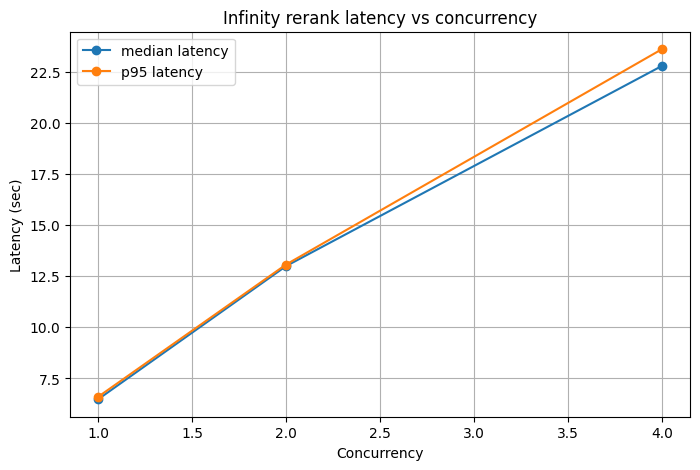

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(summary["concurrency"], summary["latency_median"], marker="o", label="median latency")
plt.plot(summary["concurrency"], summary["latency_p95"], marker="o", label="p95 latency")
plt.xlabel("Concurrency")
plt.ylabel("Latency (sec)")
plt.title("Infinity rerank latency vs concurrency")
plt.grid(True)
plt.legend()
plt.show()

# throughput 그래프

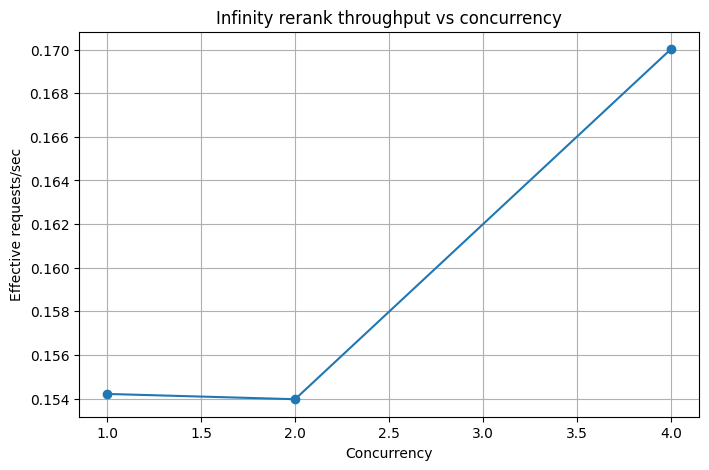

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(summary["concurrency"], summary["effective_rps"], marker="o")
plt.xlabel("Concurrency")
plt.ylabel("Effective requests/sec")
plt.title("Infinity rerank throughput vs concurrency")
plt.grid(True)
plt.show()

# 실패 요청 확인

In [19]:
df_fail = df_results[~df_results["ok"]].copy()
df_fail

,request_id,concurrency,ok,endpoint,latency_sec,status_code,error,query_words,doc_words_avg,docs_per_request,round_wall_sec,requests_per_sec_effective


In [20]:
print("query words:", estimate_words(test_payload["query"]))
print("doc[0] words:", estimate_words(test_payload["documents"][0]))
print("docs per request:", len(test_payload["documents"]))
print("top_n:", test_payload["top_n"])

query words: 53
doc[0] words: 326
docs per request: 4
top_n: 3


In [21]:
print(one["json"]["usage"])

{'prompt_tokens': 7756, 'total_tokens': 7756}


# 추가 부하 설정

### 중간 부하

DOCS_PER_REQUEST = 4
QUERY_REPEAT = 4
DOC_REPEAT = 10
TOP_N = 3

REQUESTS_PER_ROUND = 8
CONCURRENCY_LEVELS = [1, 2, 4]


### 강한 부하

DOCS_PER_REQUEST = 4
QUERY_REPEAT = 4
DOC_REPEAT = 10
TOP_N = 3

REQUESTS_PER_ROUND = 8
CONCURRENCY_LEVELS = [1, 2, 4]